# Computer Exercise 9.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 9. The Method of Least Squares
> **절**: §9.1 Linear Least Squares — *SVD / 의사역행렬 / 절단 SVD(TSVD) 정칙화*
> **풀이 일자**: Day 34
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** For a rank-deficient or severely ill-conditioned least-squares problem, compute the
> solution via the **singular value decomposition** $A=U\Sigma V^{\top}$ and the **pseudoinverse**
> $A^{+}=V\Sigma^{+}U^{\top}$. When $\mathbf{b}$ is noisy, the full pseudoinverse amplifies noise
> through small singular values; use **truncated SVD (TSVD)** to regularize. Plot the singular
> spectrum and the TSVD error vs the truncation index $k$.

### 한국어 풀이용 정리
심하게 ill-conditioned 한 최소제곱에서 **SVD** $A=U\Sigma V^\top$ 와 **의사역행렬** $A^+=V\Sigma^+U^\top$ 로 해를 구한다.
잡음이 있으면 작은 특이값이 잡음을 폭증시키므로 **절단 SVD(TSVD)** 로 정칙화한다. 특이값 스펙트럼과
절단 지수 $k$ 에 따른 오차(L-curve)를 관찰한다.

## 2. 수학적 배경

### 2.1 SVD 와 의사역행렬
$A=U\Sigma V^\top=\sum_{i=1}^{r}\sigma_i\mathbf{u}_i\mathbf{v}_i^\top$ ($\sigma_1\ge\dots\ge\sigma_r>0$). 최소노름 최소제곱해는
$$\mathbf{x}^+=A^+\mathbf{b}=\sum_{i=1}^{r}\frac{\mathbf{u}_i^\top\mathbf{b}}{\sigma_i}\mathbf{v}_i.$$

### 2.2 잡음 폭증과 Picard 조건
$\mathbf{b}=\mathbf{b}_{\text{true}}+\boldsymbol{\eta}$ 이면 잡음 기여는 $(\mathbf{u}_i^\top\boldsymbol{\eta})/\sigma_i$.
작은 $\sigma_i$ 가 분모면 잡음이 $1/\sigma_i$ 배로 폭증. *이산 Picard 조건* — $|\mathbf{u}_i^\top\mathbf{b}|$ 가 $\sigma_i$ 보다 빨리 감소 — 이 만족돼야 한다.

### 2.3 절단 SVD (TSVD)
$$\boxed{\;\mathbf{x}_k=\sum_{i=1}^{k}\frac{\mathbf{u}_i^\top\mathbf{b}}{\sigma_i}\mathbf{v}_i\;}$$
$k$ 작으면 과도한 정칙화(편향↑), 크면 잡음 폭증(분산↑). 최적 $k^\star$ 에서 총오차 최소 (편향–분산 trade-off).

## 3. 풀이 흐름

1. **이산 ill-posed 문제**: 매끄러운 가우시안 커널 적분방정식 이산화 → 특이값이 매끄럽게 0으로 감소.
2. 매끄러운 참해 $\mathbf{x}^\star$, $\mathbf{b}_{\text{true}}=A\mathbf{x}^\star$, 잡음 추가.
3. **SVD** 계산.
4. **전체 의사역해** $\mathbf{x}^+$ — 잡음 폭증 관찰.
5. **TSVD**: $k=1,\dots,n$ 별 $\mathbf{x}_k$ 와 참오차.
6. **시각화(1)**: 특이값 + Picard 계수.
7. **시각화(2)**: $k$ vs 해 오차, 최적 $k^\star$.
8. **해석**: 전체 pseudoinverse vs 최적 TSVD 해 비교.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")
rng = np.random.default_rng(9413)

n = 64
t = np.linspace(0, 1, n); s = np.linspace(0, 1, n)
S, T = np.meshgrid(s, t)
A = np.exp(-((S - T)**2) / (2 * 0.05**2)) * (1.0 / n)   # 매끄러운 커널 -> ill-posed

xstar = np.exp(-((t-0.4)**2)/(2*0.1**2)) + 0.5*np.exp(-((t-0.7)**2)/(2*0.05**2))
b_true = A @ xstar
eta = 1e-3 * np.linalg.norm(b_true)/np.sqrt(n) * rng.standard_normal(n)
b = b_true + eta

U, sig, Vt = np.linalg.svd(A, full_matrices=False); V = Vt.T
print(f"행렬 {A.shape}, cond(A) = {sig[0]/sig[-1]:.3e}")
print(f"sigma: {sig[0]:.3e} ... {sig[-1]:.3e}")

x_full = V @ ((U.T @ b) / sig)            # 전체 의사역해

ks = np.arange(1, n+1); errs = []
for k in ks:
    xk = V[:, :k] @ ((U[:, :k].T @ b) / sig[:k])
    errs.append(np.linalg.norm(xk - xstar)/np.linalg.norm(xstar))
errs = np.array(errs); k_opt = int(ks[np.argmin(errs)])
print(f"최적 절단 k* = {k_opt}, 상대오차 = {errs.min():.3e}")
print(f"전체 의사역해 상대오차 = {np.linalg.norm(x_full-xstar)/np.linalg.norm(xstar):.3e}")

행렬 (64, 64), cond(A) = 1.972e+16
sigma: 1.221e-01 ... 6.190e-18
최적 절단 k* = 18, 상대오차 = 4.497e-03
전체 의사역해 상대오차 = 3.604e+12


In [2]:
picard = pd.DataFrame({
    "i": np.arange(1, n+1), "sigma_i": sig,
    "|u_i^T b|": np.abs(U.T @ b), "|u_i^T b|/sigma_i": np.abs(U.T @ b)/sig,
})
picard.iloc[list(range(0,12)) + list(range(n-4, n))]

,i,sigma_i,|u_i^T b|,|u_i^T b|/sigma_i
0,1,1.221e-01,3.723e-01,3.050e+00
1,2,1.182e-01,7.856e-02,6.645e-01
2,3,1.121e-01,1.200e-01,1.071e+00
3,4,1.040e-01,8.834e-02,8.493e-01
4,5,9.450e-02,3.811e-02,4.033e-01
5,6,8.406e-02,6.202e-02,7.378e-01
6,7,7.321e-02,2.842e-02,3.882e-01
7,8,6.243e-02,2.943e-02,4.715e-01
8,9,5.213e-02,3.743e-03,7.180e-02
9,10,4.263e-02,4.709e-03,1.105e-01


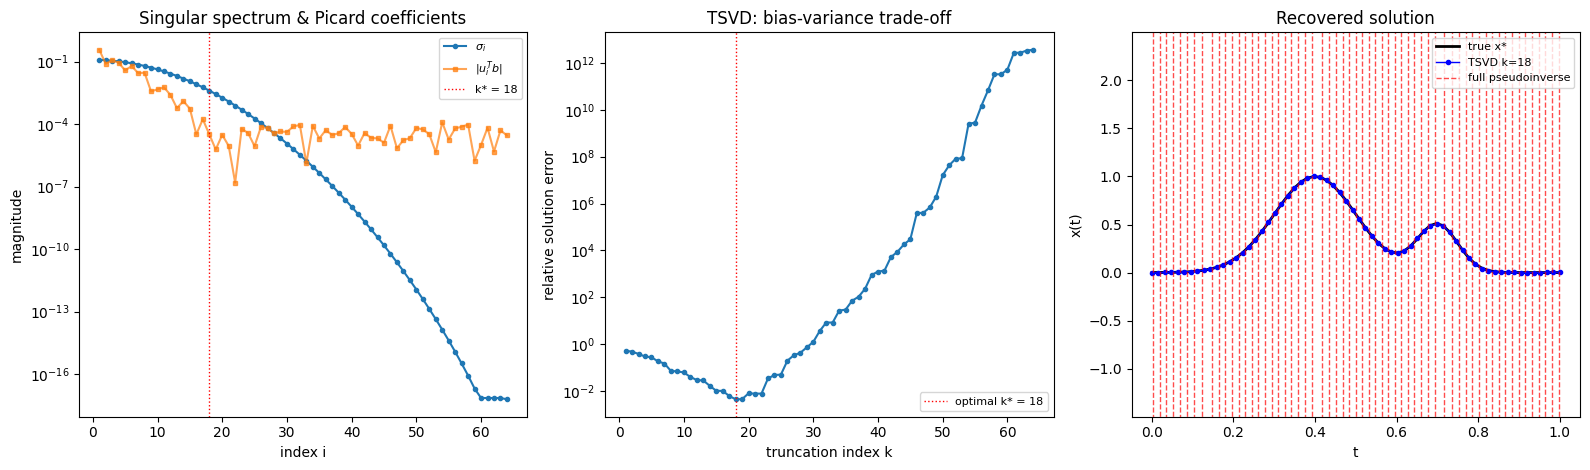

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
ax[0].semilogy(np.arange(1,n+1), sig, "o-", ms=3, label=r"$\sigma_i$")
ax[0].semilogy(np.arange(1,n+1), np.abs(U.T@b), "s-", ms=3, alpha=0.7, label=r"$|u_i^T b|$")
ax[0].axvline(k_opt, color="red", ls=":", lw=1, label=f"k* = {k_opt}")
ax[0].set_xlabel("index i"); ax[0].set_ylabel("magnitude")
ax[0].set_title("Singular spectrum & Picard coefficients"); ax[0].legend(fontsize=8)

ax[1].semilogy(ks, errs, "o-", ms=3)
ax[1].axvline(k_opt, color="red", ls=":", lw=1, label=f"optimal k* = {k_opt}")
ax[1].set_xlabel("truncation index k"); ax[1].set_ylabel("relative solution error")
ax[1].set_title("TSVD: bias-variance trade-off"); ax[1].legend(fontsize=8)

x_kopt = V[:, :k_opt] @ ((U[:, :k_opt].T @ b)/sig[:k_opt])
ax[2].plot(t, xstar, "k-", lw=2, label="true x*")
ax[2].plot(t, x_kopt, "bo-", ms=3, lw=1, label=f"TSVD k={k_opt}")
ax[2].plot(t, x_full, "r--", lw=1, alpha=0.7, label="full pseudoinverse")
ax[2].set_xlabel("t"); ax[2].set_ylabel("x(t)")
ax[2].set_title("Recovered solution")
ax[2].set_ylim(xstar.min()-1.5, xstar.max()+1.5); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **특이값의 매끄러운 붕괴**: 매끄러운 커널이라 $\sigma_i$ 가 기계정밀도까지 연속적으로 0에 수렴 — 전형적 ill-posed, 명확한 수치 rank 가 없다.
2. **Picard 그림**: 작은 $i$ 에서 $|\mathbf{u}_i^\top\mathbf{b}|$ 가 $\sigma_i$ 보다 빨리 감소(신호)하다가 잡음 바닥에서 평평 — 그 교차점이 최적 $k^\star$.
3. **전체 의사역해 폭증**: 빨간 점선은 작은 $\sigma_i$ 로 나눈 잡음이 폭증해 거칠게 진동, 참해와 닮지 않는다.
4. **TSVD 정칙화**: $k=k^\star$ 에서 매끄러운 참해를 잘 복원. 가운데 U자형 최소가 편향–분산 균형점.

### 결론
> **SVD 는 최소제곱의 가장 일반적·안정적 도구이며, 작은 특이값이 잡음을 폭증시키는 ill-posed 문제에서는
> 절단 SVD(TSVD)가 편향–분산 균형으로 해를 정칙화한다.**

### 다음 단원 연결
- §9.1(정규방정식·QR·SVD 세 기둥)을 마무리. 이후 비선형 최소제곱(가우스–뉴턴/레벤버그–마쿼트)과 직교다항식 연속 최소제곱으로 확장,
  Day 35+ 에서 Ch 10(Monte Carlo)로 진행.